In [17]:
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights


from sklearn.model_selection import train_test_split
# graphic
import matplotlib.pyplot as plt 
import numpy as np


from tqdm.auto import tqdm

from sklearn.metrics import classification_report, confusion_matrix

In [18]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [19]:
path='../asl_alphabet_train/'

In [20]:
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [21]:
dataset = datasets.ImageFolder(
    root=path,
    transform=train_transform)

print('Images:', len(dataset))
print('Clases', len(dataset.classes))

Images: 87000
Clases 29


In [22]:
class_names= dataset.classes
class_names

['A',
 'B',
 'C',
 'D',
 'DEL',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'NOTHING',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'SPACE',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z']

In [23]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    
    [train_size, test_size]
)

print(len(train_dataset))
print(len(test_dataset))

69600
17400


In [24]:

# 5. Crear los DataLaoders (los encargados de darle las imágenes en "paquetes" o batches a la ResNet)
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


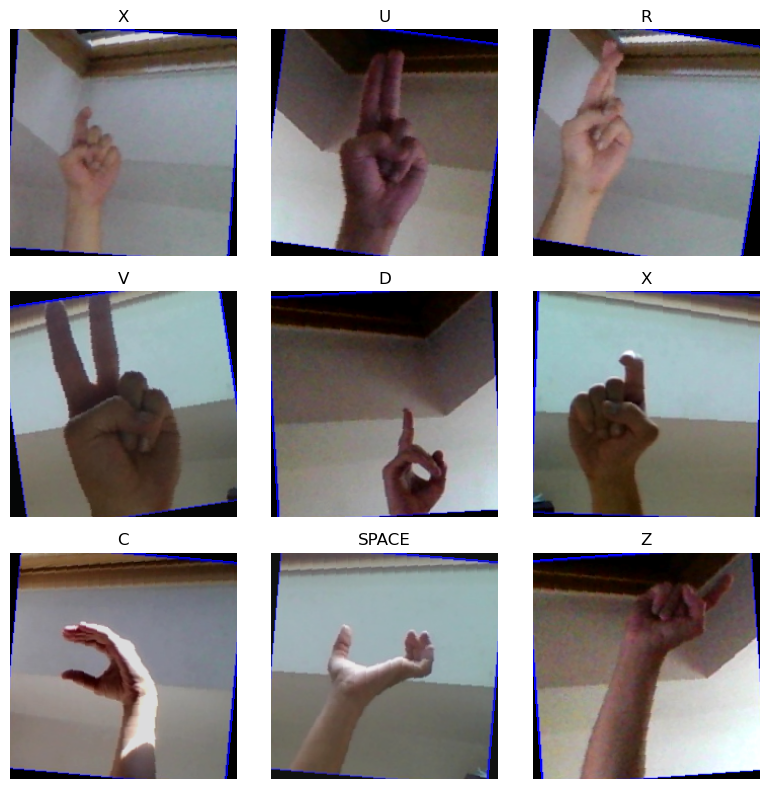

In [25]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3,3,figsize=(8,8))

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1,2,0).numpy()

    img = img * [0.229,0.224,0.225]
    img = img + [0.485,0.456,0.406]

    img = np.clip(img,0,1)

    ax.imshow(img)

    ax.set_title(
        class_names[labels[i]]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
weights= ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

In [27]:
for param in model.parameters():
    param.requires_grad = True

In [28]:
# 2. Vemos cuántas entradas tenía su última capa lineal original
num_ftrs = model.fc.in_features  # En ResNet-18 suele ser 512

num_ftrs

output_classes=29

model.fc=nn.Linear(num_ftrs,output_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.fc.parameters(),lr=1e-4)

In [29]:
scaler=torch.amp.GradScaler('cuda')

In [30]:
def train_step(model, loader):
    model.train()
    
    total_loss=0
    total_correct=0

    for X,y in tqdm(loader):

        X =X.to(device)
        y =y.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):

            preds= model(X)

            loss = criterion(preds,y)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        total_loss += loss.item()
        total_correct += (preds.argmax(1) == y ).sum().item()

    loss = total_loss / len(loader)

    acc = total_correct / len(loader.dataset)

    return loss,acc
            

In [31]:
def test_step(model,loader):

    model.eval()

    total_loss = 0
    total_correct = 0

    with torch.inference_mode():
        for X,y in loader:

            X = X.to(device)
            y = y.to(device)

            preds = model(X)

            loss = criterion(preds,y)

            total_loss += loss.item()

            total_correct += (preds.argmax(1) == y).sum().item()

        loss = total_loss / len(loader.dataset)

        acc = total_correct / len(loader.dataset)

        return loss, acc

In [32]:
EPOCHS = 13

history = { 
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": []
}

best_acc=0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_step(model,train_loader)

    test_loss, test_acc = test_step(model, test_loader)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if test_acc > best_acc:

        best_acc = test_acc

        torch.save(model.state_dict(),"best_signnet01.pth")

    print(f"Epoch [{epoch+1}/{EPOCHS}]"
          f"train Acc={train_acc:.4f}"
          f"Test Acc={test_acc:.4f}"
)
    

  0%|          | 0/2175 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"])

plt.plot(history["test_acc"])

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"])

plt.plot(history["test_loss"])

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [ ]:
y_true = []
y_pred = []

model.eval()

with torch.inference_mode():

    for X, y in test_loader:

        X = X.to(device)

        preds = model(X)

        preds = preds.argmax(1)

        y_true.extend(
            y.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12,12))

plt.imshow(cm)

plt.colorbar()

plt.title("Confusion Matrix")

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "signnet_final01.pth"
)

print("Saved")

In [ ]:
# Cargar el modelo guardado y ponerlo en modo evaluación
model_nuevo = resnet18(weights=None)
model_nuevo.fc = nn.Linear(num_ftrs, output_classes)
model_nuevo.load_state_dict(torch.load("signnet_final.pth", map_location=device))
model_nuevo = model_nuevo.to(device)
model_nuevo.eval()

print("Loaded signnet_final.pth and set model_nuevo to eval mode")

In [ ]:
torch.save(
    model.state_dict(),
    "signnet02.pth"
)

print("Saved")